In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/blood.csv')
df

,Recency,Frequency,Monetary,Time,Class
0,2,50,12500,99,1
1,0,13,3250,28,1
2,1,17,4000,36,1
3,2,20,5000,45,1
4,1,24,6000,77,0
...,...,...,...,...,...
743,23,2,500,38,0
744,21,2,500,52,0
745,23,3,750,62,0
746,39,1,250,39,0


Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 748 entries, 0 to 747
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Recency    748 non-null    int64
 1   Frequency  748 non-null    int64
 2   Monetary   748 non-null    int64
 3   Time       748 non-null    int64
 4   Class      748 non-null    int64
dtypes: int64(5)
memory usage: 29.3 KB


In [4]:
df.isnull().sum()

,0
Recency,0
Frequency,0
Monetary,0
Time,0
Class,0


In [5]:
df.duplicated().sum()

np.int64(215)

In [6]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe()

,Recency,Frequency,Monetary,Time,Class
count,533.000000,533.000000,533.000000,533.000000,533.00000
mean,9.529081,6.992495,1747.654784,42.307692,0.27955
std,8.250860,6.268727,1566.468760,23.299276,0.44920
min,0.000000,1.000000,250.000000,2.000000,0.00000
25%,3.000000,3.000000,750.000000,26.000000,0.00000
50%,8.000000,5.000000,1250.000000,38.000000,0.00000
75%,14.000000,9.000000,2250.000000,58.000000,1.00000
max,74.000000,50.000000,12500.000000,99.000000,1.00000


In [10]:
df.rename(columns={"Time":"Time(month)","Class":"Donated Blood"},inplace=True)

In [11]:
df.head()

,Recency,Frequency,Monetary,Time(month),Donated Blood
0,2,50,12500,99,1
1,0,13,3250,28,1
2,1,17,4000,36,1
3,2,20,5000,45,1
4,1,24,6000,77,0


1 stands for Donating blood

0 stands for not Donating blood

In [13]:
df["Donated Blood"].value_counts()

,count
Donated Blood,
0,384
1,149


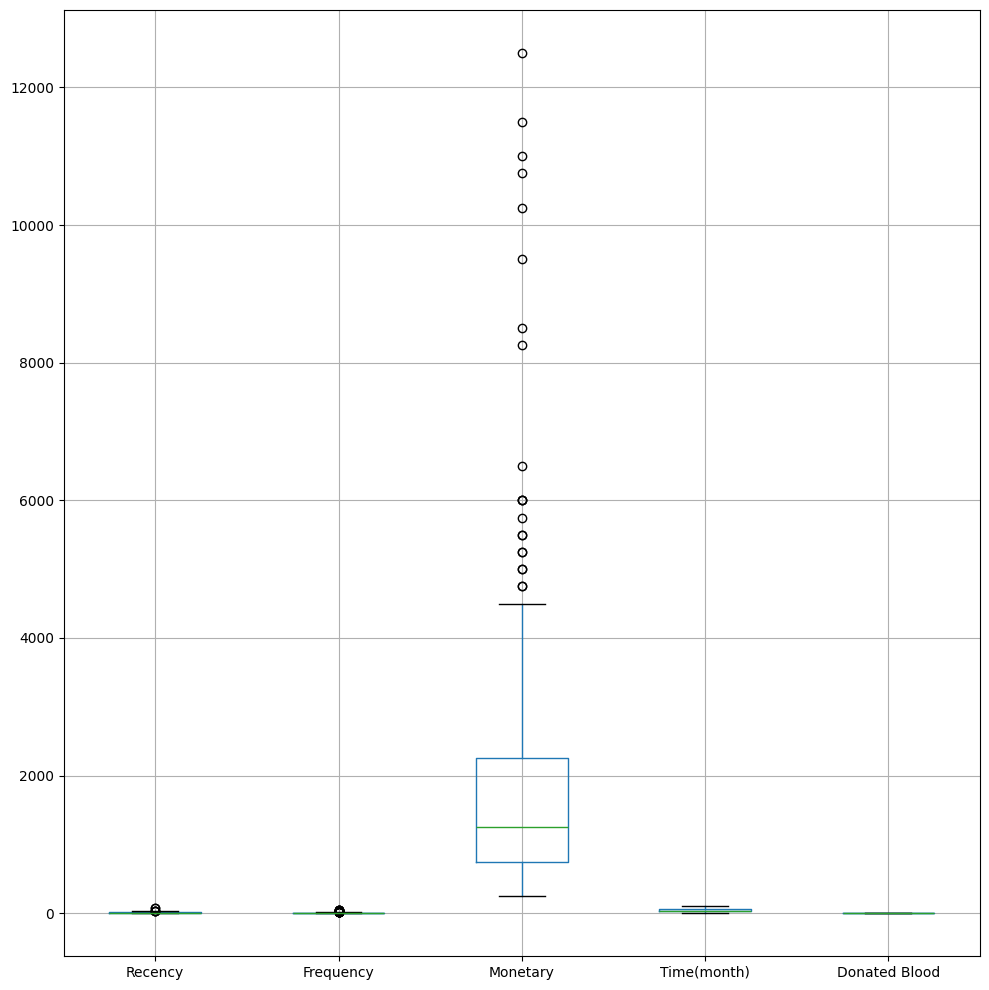

In [26]:
# Use a larger figure size for better layout
_ = df.boxplot(figsize=(10, 10))

# Adjust layout to prevent label overlap
plt.tight_layout()

# Show the plots
plt.show()

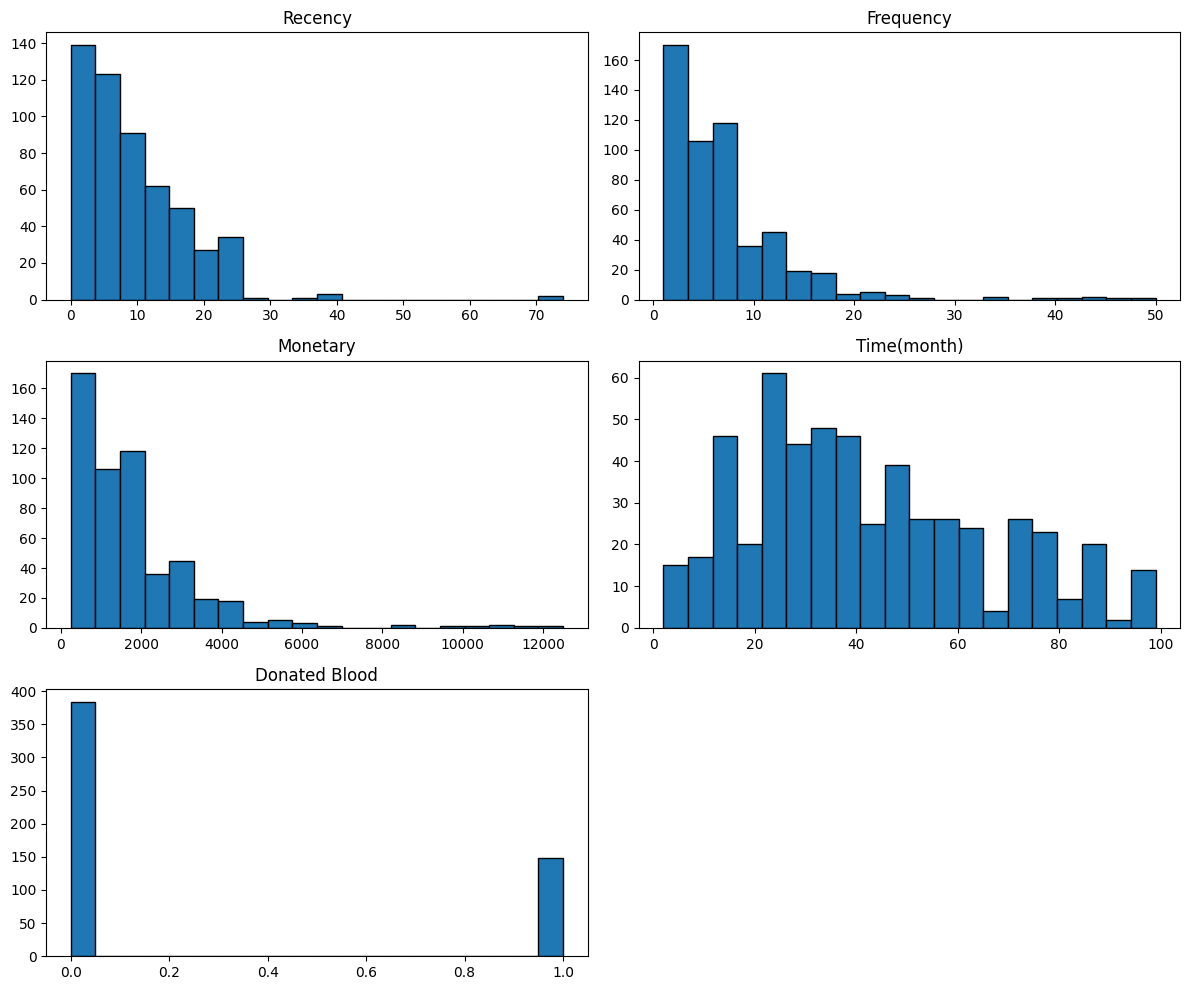

In [25]:
# Use a larger figure size for better layout
_ = df.hist(figsize=(12, 10),bins=20, edgecolor='black', grid=False) # Removed the bins parameter

# Adjust layout to prevent label overlap
plt.tight_layout()

# Show the plots
plt.show()

<Axes: >

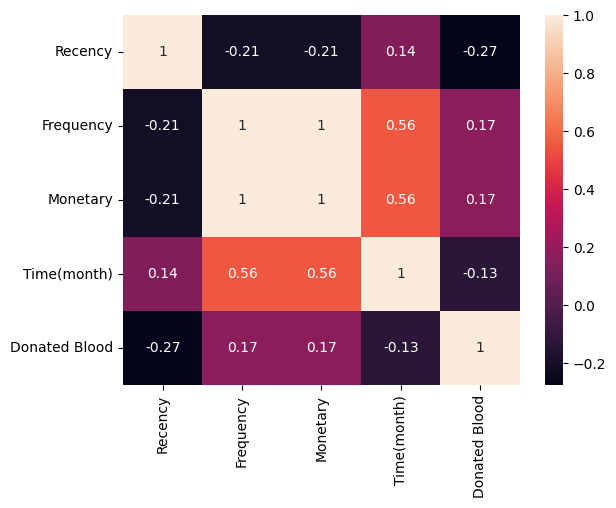

In [19]:
sns.heatmap(df.corr(),annot=True)

In [27]:
x=df[['Recency', 'Frequency', 'Monetary','Time(month)']]
y=df['Donated Blood']

Logistic Regression

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [31]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 3. Standard Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Logistic Regression Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 5. Predictions
y_pred = model.predict(X_test_scaled)

# 6. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# 7. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


Accuracy: 0.77
[[75  5]
 [20  7]]
